This code allows for the following: 

Imports: 
.txt files with distributions of a full contact potential difference image. 

Functions:
- Fitting individual gaussians with fit centre marked and FWHM shaded. 
- Plots raw data and fitted distributions on same plot for comparison. 


Use for: 
- Comparing CPD distributions of different images. 
- Comparing spread


In [111]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [112]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()

def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=600, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

In [113]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink


GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

In [114]:
#Fitting for multi-gaussian
#Adjust peak width tolerance accordingly

# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

In [115]:
# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 3:
        #sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        sorted_indices = np.argsort(y_smooth[peaks])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        x_range = np.ptp(x)
        wid =x_range/50 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [ ]:
#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_path, rows, linecolour, name, save_path=None, measurement=''):

    #Plotting parameters
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 6
    line_width = 1.5
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length, labelsize = base_font_size)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    ax.autoscale(enable=None, axis="x", tight=True)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    #print(f"\nProcessing file: {filename}") #Use if you want each individual file processed

    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)

    x_data = data[:, 0]
    y_data = data[:, 1]
    # Estimate initial guess and peak count
    initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    # Uncomment if you want to use a specific number of points for fitting (or if there are few raw data points)
    #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    popt, pcov = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=1000000)
    y_fit=multi_gaussian(x_data,*popt)
    peak_index_max=np.argmax(y_fit)
    x_peak_centre=x_data[peak_index_max]
    perr=np.sqrt(np.diag(pcov))
    #For finding min and max *i.e. either side of the peaks. 
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})
    
    # Identify the highest peak
    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    sigma=highest['wid']
    fwhm = 2.355 *sigma # to make mV
    x_left = highest['cen'] - fwhm / 2
    x_right = highest['cen'] + fwhm / 2
    
    # Store in lists for output

    # Optional: print for debugging
    # 3. Create the summary text for the plot
    statistics=(f"Peak: {highest['cen']*1000:.3f} mV\n"
                f"Error: {np.sqrt(pcov[1,1])*1000:.3f}mV\n"
              f"FWHM: {fwhm*1000:.2f} mV\n"
              f"Error: {np.sqrt(pcov[2,2])*2.355*1000:.3f}mV\n"
              f"FWHM Bounds: [{x_left*1000:.2f}, {x_right*1000:.2f}]mV\n"
              f"Sigma: {sigma*1000:.3f} mV\n"
              f"Error: {np.sqrt(pcov[2,2])*1000:.3f}mV\n")
        
    print(statistics) 

    if save_path is not None:
        output_file = os.path.join(save_path, f'Statistics_{name}.txt')
        with open(output_file, 'w') as f: 
           f.write(statistics)
    else: 
        print("Cannot save statistics, continuing")

    
    if n_peaks is not None:
        x_datamV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in x_data]
        # Shading spread and peak centre
        ax.axvspan(x_left*1000, x_right*1000, color='gray', alpha=0.2, label='FWHM Region', zorder=0)
        ax.axvline(x=highest['cen']*1000, color='black', linestyle='--', linewidth=line_width, label='Peak Center', zorder=4)
        #Raw data and fitted gaussian: 
        ax.scatter(x_datamV, y_data, label=f"name",color=linecolour, s=scatter_size, zorder=2)
        ax.plot(x_datamV, y_fit, label=f"_nolegend_", color=linecolour,linewidth=line_width, zorder=3)
        ax.set_xlabel(f"{measurement}(mV)", size = base_font_size)
        ax.set_ylabel("Distribution $V^{-1}$", size = base_font_size)
        ax.autoscale()
        #plt.legend()
        plt.tight_layout()
        #plt.show()
    y_fit = multi_gaussian(x_data, *popt)
    #plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
    if save_path: 
        fig=plt.gcf()
        save_plot_to_folder(fig,save_path,filename=f'AnnotatedFit_{name}.jpeg')
        plt.show()
    else: 
        print("No save path given")
        plt.show()

    return x_data, y_data, y_fit, statistics, perr
    plt.show()

In [117]:
def comparison_plot(sample1_fit, sample1_x, sample1_y, sample2_fit, sample2_x, sample2_y, save_path=None, measurement='', sample1_name = '', sample2_name='' ):
    sample1_x_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in sample1_x]
    sample2_x_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in sample2_x]
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 15
    scatter_size = 6
    line_width = 1.5


    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)")
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Max 5 ticks on y-axis    
    ax.scatter(sample1_x_mV, sample1_y, label=f"_nolegend_",color=GI_U_color, s=scatter_size, zorder=2)
    ax.plot(sample1_x_mV, sample1_fit, label="Horizontal", color=GI_U_color,linewidth=line_width, zorder=3)
    ax.scatter(sample2_x_mV, sample2_y, label=f"_nolegend_",color=GI_P_color, s=scatter_size, zorder=2)
    ax.plot(sample2_x_mV, sample2_fit, label="Vertical", color=GI_P_color,linewidth=line_width, zorder=3)
    ax.set_xlabel(f"{measurement}(mV)")
    ax.set_ylabel("Distribution $V^{-1}$")
    ax.autoscale()
    plt.margins(0.1,0)
    plt.legend(loc='best', fontsize=legend_font)
    plt.tight_layout()

    if save_path: 
        fig=plt.gcf()
        save_plot_to_folder(fig,save_path,filename=f'Comparison.jpeg')
        plt.show()
    else: 
        print("No save path given")
        plt.show()
        
    


In [118]:
print("If pop up box not seen minimise and select folder wanted for analysis")
file_path_sample1 = filedialog.askopenfilename(title='Select sample1 .txt file')
file_path_sample2 = filedialog.askopenfilename(title='Select sample2 .txt file')
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')
if not save_path: 
    print("no save path")

If pop up box not seen minimise and select folder wanted for analysis


Peak: 688.530 mV
Error: 0.954mV
FWHM: 83.44 mV
Error: 2.247mV
FWHM Bounds: [646.81, 730.25]mV
Sigma: 35.431 mV
Error: 0.954mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/Plotting/CPD_OFF2\AnnotatedFit_DL.jpeg


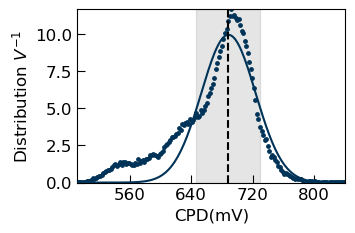

Peak: -2242.959 mV
Error: 0.552mV
FWHM: 222.34 mV
Error: 1.300mV
FWHM Bounds: [-2354.13, -2131.79]mV
Sigma: 94.411 mV
Error: 0.552mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/Plotting/CPD_OFF2\AnnotatedFit_AL.jpeg


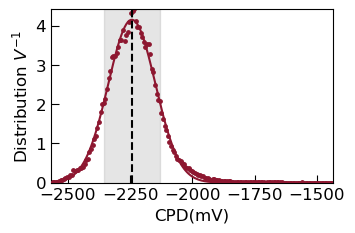

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/Plotting/CPD_OFF2\Comparison.jpeg


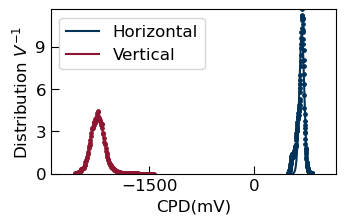

In [ ]:
#Running all plots:

#Input measurement type below: 
measurement = input("Please state whether using CPD or SPV as you need in the x-axis label (without units)")
sample1_name ="SAMPLE1"
sample2_name = "SAMPLE2"
# Fitting individual and plotting, saving figures and adding annotations
sample1_x, sample1_y, sample1_fit,sample1_stats, perr_sample1 = multi_gaussian_folder(file_path_sample1, rows=3, linecolour=GI_U_color, name=sample1_name, save_path=save_path, measurement=measurement)
sample2_x, sample2_y, sample2_fit,sample2_stats, perr_sample2 = multi_gaussian_folder(file_path_sample2, rows=3, linecolour=GI_P_color, name=sample2_name, save_path=save_path, measurement=measurement)
# Plotting for both
comparison_plot(sample1_fit, sample1_x, sample1_y, sample2_fit, sample2_x, sample2_y, save_path, measurement)